# VEP

Variant Effect Prediction (VEP) using Protein Language Models.

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
os.chdir(os.path.dirname(os.path.abspath('.')))

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import data

### Candidate proteins
A curated list of proteins that clinically relevant and incompletely penetrant across different ethnic populations.


### ProteinGym clinical mutations
Import set of clinical variants (substitutions and indels) to use for perturbing the wild-type protein sequences *in silico*.

In [4]:
proteins_df = pg.merge_resources(rows_per_id=None)
proteins_df

Gathering resources:   0%|          | 0/2 [00:00<?, ?it/s]

Gathering resources: 100%|██████████| 2/2 [00:00<00:00, 41.34it/s]


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP
0,NP_071398.5,NP_071398,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_071398.5,PRDM15,ENSG00000141956,ENST00000269844,ENSP00000269844
1,NP_001153844.1,NP_001153844,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001153844.1,TRAPPC9,ENSG00000167632,ENST00000648948,ENSP00000498020
2,NP_060206.2,NP_060206,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_060206.2,NaN,NaN,NaN,NaN
3,NP_001243718.1,NP_001243718,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_001243718.1,NaN,NaN,NaN,NaN
4,NP_002878.2,NP_002878,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_002878.2,RARS,ENSG00000113643,ENST00000231572,ENSP00000231572
...,...,...,...,...,...,...,...,...,...
4774,NP_002070.1,NP_002070,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_002070.1,NaN,NaN,NaN,NaN
4775,NP_619636.2,NP_619636,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_619636.2,TMC1,ENSG00000165091,ENST00000297784,ENSP00000297784
4776,UPI0000E5AEF3,UPI0000E5AEF3,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI0000E5AEF3,NaN,NaN,NaN,NaN
4777,NP_006261.1,NP_006261,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_006261.1,NaN,NaN,NaN,NaN


In [5]:
candidate_proteins = utils.get_candidate_proteins()
candidate_proteins['protein'] = candidate_proteins['RefSeq Protein']
# candidate_proteins = er.map_ids(df=candidate_proteins,
#                                 input_col="RefSeq Protein")
candidate_proteins = pg.map_resources(df=candidate_proteins)
candidate_proteins

Mapping Proteingym IDs
Loading mapping file from /home/schilder/.cache/ProteinGym/proteingym_id_map_693de35055033c431bc1452512841718.csv.gz


,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,RefSeq Protein Stable,protein,genename,ENSG,ENST,ENSP
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,NP_001346945,NP_001346945.1,NaN,NaN,NaN,NaN
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,NP_000401,NP_000401.1,HFE,ENSG00000010704,ENST00000357618,ENSP00000417404
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,NP_000483,NP_000483.3,CFTR,ENSG00000001626,ENST00000003084,ENSP00000003084
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,NP_009225,NP_009225.1,BRCA1,ENSG00000012048,ENST00000357654,ENSP00000350283
4,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,NP_009225,NP_009225.1,BRCA1,ENSG00000012048,ENST00000352993,ENSP00000312236
5,BRCA2,Breast Cancer Type 2 Susceptibility Protein,NP_000050.3,NM_000059.4,NP_000050,NP_000050.3,NaN,NaN,NaN,NaN
6,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,NP_000121,NP_000121.2,F5,ENSG00000198734,ENST00000367797,ENSP00000356771
7,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,NP_000509,NP_000509.1,HBB,ENSG00000244734,ENST00000335295,ENSP00000333994
8,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,NP_000286,NP_000286.3,SERPINA1,ENSG00000197249,ENST00000440909,ENSP00000390299
9,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,NP_000518,NP_000518.1,LDLR,ENSG00000130164,ENST00000558518,ENSP00000454071


### Haplotypes
Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [7]:
# Download and import haplotypes (includes lots of other data/metadata)
haplotypes = hs.get_haplotypes(tx_ids=candidate_proteins["ENST"],
                              #  use_protein_ids=True, 
                               
                            #    max_tx_ids=10, # Can limit to a subset of transcripts for testing
                              #  cache_only=True # Set to true to speed up subsequent runs by only import from cache. Set to False if you're running this for the first time.
                               )

Getting haplotypes:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

`filter_prot_df` provides a convenient way to filter the ProteinGym mutations according to which ones are present in the 1KG haplotypes data,   
as well as which ones are present in the candidate proteins.

It will automatically figure out which `proteins_df` columns in it should be filtering on according to the prefixes in the `protein_ids` ('ENSP' or 'ENST' or 'protein') and `haplotypes` ('ENSP' or 'ENST').

It can also filter by the types of mutations you wish to inject during the VEP procedure (see the 'source_type' column for available options).

The final product is the filtered `proteins_df`, which we store as a new DataFrame `prot_df`.

In [8]:
prot_df = vp.filter_prot_df(proteins_df,
#                             protein_ids=candidate_proteins["ENSP"],
                            haplotypes=haplotypes,
                            source_types="clinical_ProteinGym_substitutions",
                            )
prot_df

Filtering by 1 source types
Filtering by ENST haplotypes


Getting haplotype sequences:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Returning 9 unique proteins


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP,proteingym_seq_len,haplosaurus_seq_len,proteingym_haplosaurus_seq_sim,proteingym_haplosaurus_seq_identical
660,NP_000209.2,NP_000209,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000209.2,KCNQ1,ENSG00000053918,ENST00000155840,ENSP00000155840,[676],[676],1.0,True
1048,NP_000401.1,NP_000401,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,HFE,ENSG00000010704,ENST00000357618,ENSP00000417404,[348],[348],1.0,True
1153,NP_000483.3,NP_000483,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000483.3,CFTR,ENSG00000001626,ENST00000003084,ENSP00000003084,[1480],[1480],1.0,True
1498,NP_000518.1,NP_000518,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000518.1,LDLR,ENSG00000130164,ENST00000558518,ENSP00000454071,[860],[860],1.0,True
1630,NP_000509.1,NP_000509,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000509.1,HBB,ENSG00000244734,ENST00000335295,ENSP00000333994,[147],[147],1.0,True
2540,NP_000121.2,NP_000121,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000121.2,F5,ENSG00000198734,ENST00000367797,ENSP00000356771,[2224],[2224],1.0,True
3153,NP_009225.1,NP_009225,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,BRCA1,ENSG00000012048,ENST00000357654,ENSP00000350283,[1863],[1863],1.0,True
3501,NP_000229.1,NP_000229,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000229.1,KCNH2,ENSG00000055118,ENST00000262186,ENSP00000262186,[1159],[1159],1.0,True
3822,NP_000286.3,NP_000286,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000286.3,SERPINA1,ENSG00000197249,ENST00000440909,ENSP00000390299,[418],[418],1.0,True


We also need to remove any suspicious proteins that have a different reference sequence lengths in the Haplosaurus haplotypes and the ProteinGym mutations   
(which suggests that the ProteinGym proteins are not exactly the same as the Haplosaurus ones).

In [9]:
prot_df = vp.add_sequence_checks(prot_df,
                                  haplotypes=haplotypes)
prot_df = prot_df.loc[prot_df['proteingym_haplosaurus_seq_identical'] == True]
prot_df

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP,proteingym_seq_len,haplosaurus_seq_len,proteingym_haplosaurus_seq_sim,proteingym_haplosaurus_seq_identical
660,NP_000209.2,NP_000209,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000209.2,KCNQ1,ENSG00000053918,ENST00000155840,ENSP00000155840,[676],[676],1.0,True
1048,NP_000401.1,NP_000401,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,HFE,ENSG00000010704,ENST00000357618,ENSP00000417404,[348],[348],1.0,True
1153,NP_000483.3,NP_000483,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000483.3,CFTR,ENSG00000001626,ENST00000003084,ENSP00000003084,[1480],[1480],1.0,True
1498,NP_000518.1,NP_000518,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000518.1,LDLR,ENSG00000130164,ENST00000558518,ENSP00000454071,[860],[860],1.0,True
1630,NP_000509.1,NP_000509,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000509.1,HBB,ENSG00000244734,ENST00000335295,ENSP00000333994,[147],[147],1.0,True
2540,NP_000121.2,NP_000121,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000121.2,F5,ENSG00000198734,ENST00000367797,ENSP00000356771,[2224],[2224],1.0,True
3153,NP_009225.1,NP_009225,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,BRCA1,ENSG00000012048,ENST00000357654,ENSP00000350283,[1863],[1863],1.0,True
3501,NP_000229.1,NP_000229,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000229.1,KCNH2,ENSG00000055118,ENST00000262186,ENSP00000262186,[1159],[1159],1.0,True
3822,NP_000286.3,NP_000286,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000286.3,SERPINA1,ENSG00000197249,ENST00000440909,ENSP00000390299,[418],[418],1.0,True


## Run VEP pipeline

Run the VEP pipeline which iterates VEP over a series of models/proteins/haplotypes/variant source types/scoring strategies. 

The results are saved in a folder structure:  
{save_dir}/  
    {model}/  
    {protein_id}/  
        {haplotype}/  
        {source_type}/  
            {scoring_strategy1}.csv.gz  
            {scoring_strategy2}.csv.gz  
            {scoring_strategy3}.csv.gz  

List all models currently supported by the VEP pipeline.

In [10]:
vp.list_models(as_list=False)

Available models:
- esm1_t12_85M_UR50S
- esm1_t34_670M_UR100
- esm1_t34_670M_UR50D
- esm1_t34_670M_UR50S
- esm1_t6_43M_UR50S
- esm1b_t33_650M_UR50S
- esm1v_t33_650M_UR90S
- esm1v_t33_650M_UR90S_1
- esm1v_t33_650M_UR90S_2
- esm1v_t33_650M_UR90S_3
- esm1v_t33_650M_UR90S_4
- esm1v_t33_650M_UR90S_5
- esm2
- esm2_t12_35M_UR50D
- esm2_t30_150M_UR50D
- esm2_t33_650M_UR50D
- esm2_t36_3B_UR50D
- esm2_t48_15B_UR50D
- esm2_t6_8M_UR50D
- esm_if1_gvp4_t16_142M_UR50
- esm_msa1_t12_100M_UR50S
- esm_msa1b_t12_100M_UR50S
- esmfold_structure_module_only_150M
- esmfold_structure_module_only_150M_270K
- esmfold_structure_module_only_15B
- esmfold_structure_module_only_35M
- esmfold_structure_module_only_35M_270K
- esmfold_structure_module_only_3B
- esmfold_structure_module_only_3B_270K
- esmfold_structure_module_only_650M
- esmfold_structure_module_only_650M_270K
- esmfold_structure_module_only_8M
- esmfold_structure_module_only_8M_270K
- esmfold_v0
- esmfold_v1


Run VEP pipeline and store the results in `save_dir`.

In [12]:
save_dir = os.path.join(config.DATA_DIR,"1KG","vep")

In [ ]:
save_paths = vp.vep_pipeline(
    prot_df = prot_df,
    haplotypes = haplotypes,
    save_dir = save_dir,
    models = [
#         "esm1_t6_43M_UR50S",
#           "esm1_t34_670M_UR50D",
#           "esm1v_t33_650M_UR90S_1",
#           "esm1b_t33_650M_UR50S",
        #   "esm2_t12_35M_UR50D",
        #   "esm2_t33_650M_UR50D",
          "esm2_t48_15B_UR50D",
#           "esmfold_v1"
             ],
    scoring_strategies = [
        "wt-marginals", 
        "masked-marginals",
#         "pseudo-ppl" # Takes much longer to run
        ],
    source_types = ["clinical_ProteinGym_substitutions"],
#     verbose = False
    )
print(len(save_paths),"results files generated.")

Getting haplotype sequences:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Filtering by 1 source types
Filtering by ENST haplotypes
Returning 9 unique proteins
Filtered 0 / 9 proteins due to sequences being too long for model 'esm2_t48_15B_UR50D'


Processing proteins:   0%|          | 0/9 [00:00<?, ?it/s]

Processing haplotypes:   0%|          | 0/47 [00:00<?, ?it/s]

Processing scoring strategies:   0%|          | 0/2 [00:00<?, ?it/s]

/home/schilder/miniconda3/envs/esm2/lib/python3.13/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t48_15B_UR50D.pt" to /home/schilder/.cache/torch/hub/checkpoints/esm2_t48_15B_UR50D.pt


## Explore VEP results

Automatically search for, import, and merge the VEP results. 
You can import only subsets of results by setting the save_dir to a lower level, e.g.: 
`os.path.join(save_dir,{model_name},{protein_id}})`

Setting `add_metadata=True` will automatically import additional variant-level metadata (collected from ProteinGym) which will be helpful for downstream plotting/analysis tasks.

### Merge VEP results files
Merge individual VEP files into one large dataframe.

In [7]:
vep_df = va.merge_vep(add_metadata=True)

No save_dir provided, using: /grid/koo/home/schilder/projects/data/1KG/vep
Found 1696 wt-marginals parquet files


Reading files: 100%|██████████| 1696/1696 [00:15<00:00, 108.94it/s]


Found 1696 masked-marginals parquet files


Reading files: 100%|██████████| 1696/1696 [00:17<00:00, 98.82it/s] 


Found 0 pseudo-ppl parquet files


Gathering resources: 100%|██████████| 2/2 [00:00<00:00, 22.17it/s]
/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3301: DtypeWarning: Columns (0,47) have mixed types.Specify dtype option on import or set low_memory=False.
  if await self.run_code(code, result, async_=asy):


In [8]:
vep_df.head()

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,...,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,W10R,MGPWGWKLRRTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-0.428001,wt-marginals,False,esm1_t6_43M_UR50S,...,"ClinGen:CA10584725|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-2.108518,-0.002561,7,likely_path
1,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15P,MGPWGWKLRWTVALPLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-5.537646,wt-marginals,False,esm1_t6_43M_UR50S,...,"ClinGen:CA10584732|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-6.361703,-0.008103,7,likely_path
2,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15R,MGPWGWKLRWTVALRLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-5.259839,wt-marginals,False,esm1_t6_43M_UR50S,...,NaN,NaN,NaN,NaN,NaN,NaN,-6.943518,-0.011925,7,likely_path
3,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,A18V,MGPWGWKLRWTVALLLAVAGTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,-0.480459,wt-marginals,False,esm1_t6_43M_UR50S,...,ClinGen:CA16602290,NaN,NaN,NaN,NaN,NaN,-0.349066,-0.000457,7,likely_benign
4,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,G20R,MGPWGWKLRWTVALLLAAARTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,-2.359585,wt-marginals,False,esm1_t6_43M_UR50S,...,"ClinGen:CA023728|LDLR-LOVD,_British_Heart_Foun...",NaN,NaN,NaN,NaN,NaN,-0.693519,-0.002438,7,benign


### Check out of frame mutants

These should all be filtered out automatically by the vep_pipeline, but just to check.

In [ ]:
# Import haplotypes if not already defined
if 'haplotypes' not in locals():
    haplotypes = hs.get_haplotypes(
        cache_only=True
    )

# Add haplotype sequences to the VEP dataframe
vep_df = va.add_mutant_out_of_frame(vep_df, 
                                    haplotypes=haplotypes)


# Check if any haplotypes with variants that are out of frame
print(vep_df.loc[vep_df['mutant_out_of_frame']==True]['haplotype'].unique())

vep_df
# Filter out variants that are out of frame, as they should not not be able to produce a VEP
# vep_df = vep_df.loc[vep_df['mutant_out_of_frame']==False]

In [19]:
# haplotypes = hs.get_haplotypes(
#     cache_only=True 
#     ) 
# vep_df['protein_id'] = vep_df['haplotype'].str.split(':').str[0]

# vep_df = hs.add_haplotype_freqs(df= vep_df, 
#                                 haplotypes = haplotypes, 
#                                 haplotype_col = "haplotype")
# vep_df.head() 

In [2]:
seq_check_df, clinsig_counts, mutant_in_haplotype = va.report_vep(vep_df)
display(seq_check_df, clinsig_counts, mutant_in_haplotype)

NameError: name 'vep_df' is not defined

## Plots: All Proteins

### Density plots

Filtered 0.7% of rows with NAs in col 'VEP'


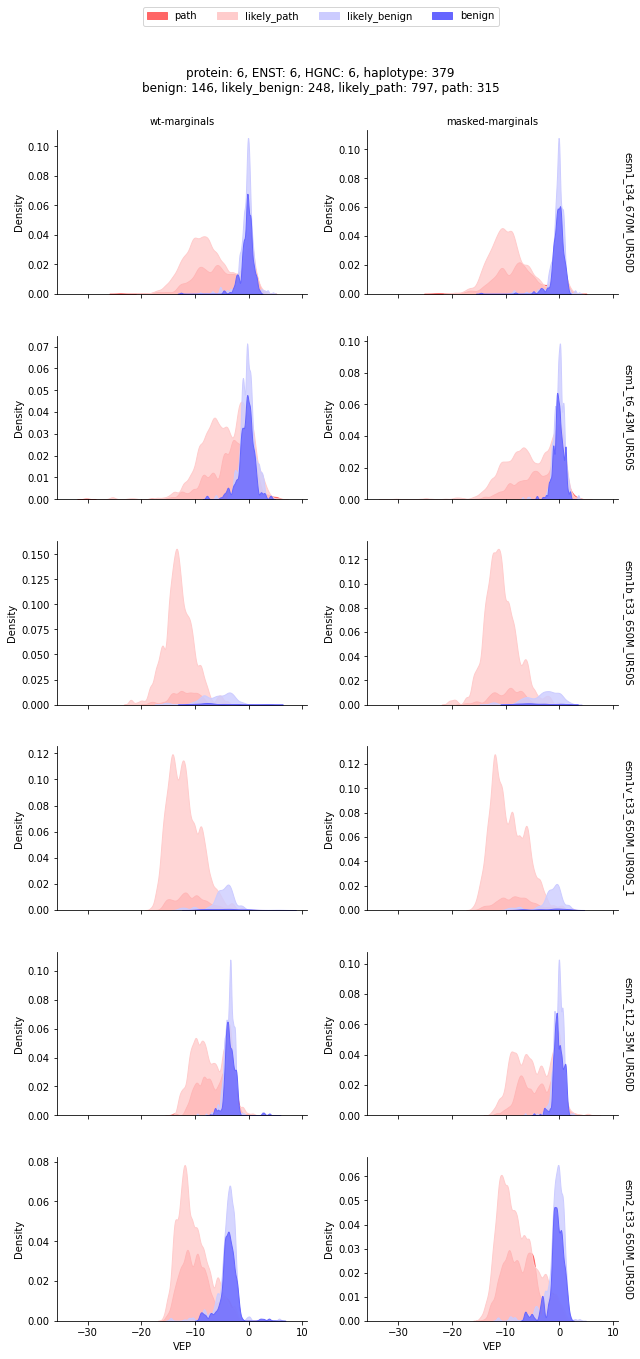

In [4]:
va.plot_vep_density(vep_df, 
                     multiple=['layer','stack','fill'][0]
                     )

### Variance plots

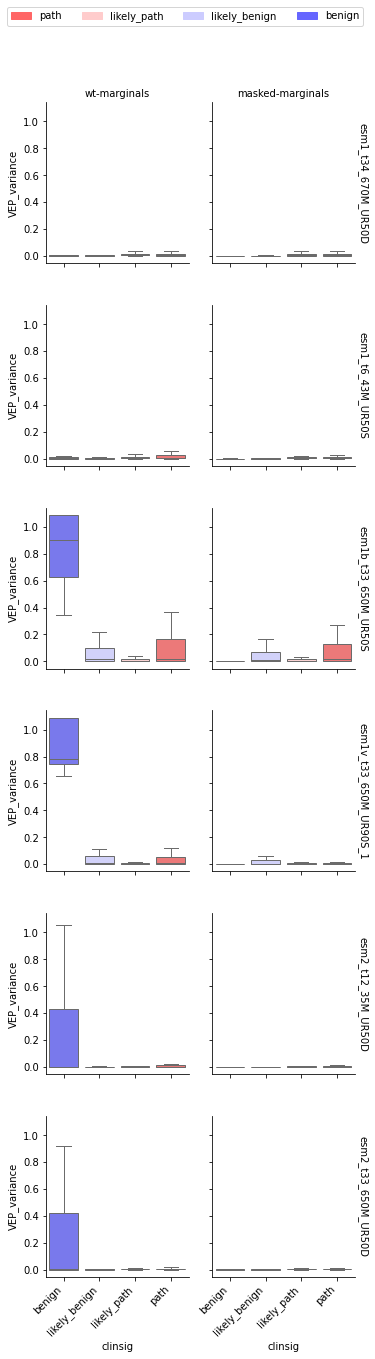

In [11]:
vep_variance = va.plot_vep_variance(vep_df, 
                                    return_df=True,
                                    showfliers=False,
                                    groupby_cols = ['model_location','protein',
                                                    'clinsig','mutant','scoring_strategy']
                                                    )

### Benign/Pathogenic Ratio

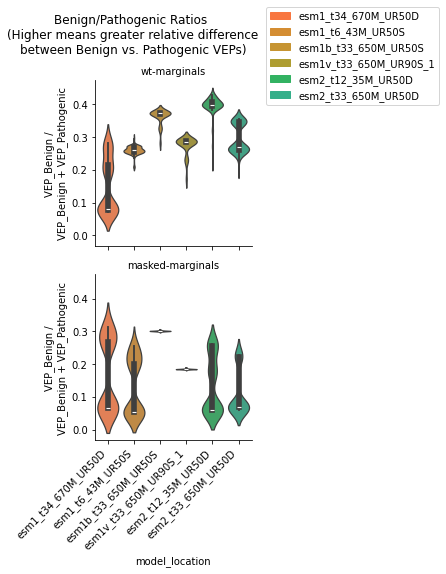

In [12]:
vep_pbratios = va.plot_vep_bpratios(vep_df,
                                     y=['benign_path_ratio','benign_path_ratio_strict'][1]
                                     )

## Plots: Single Protein

### Violin plots: wt-marginals

Filtered 0.0% of rows with NAs in col 'VEP'


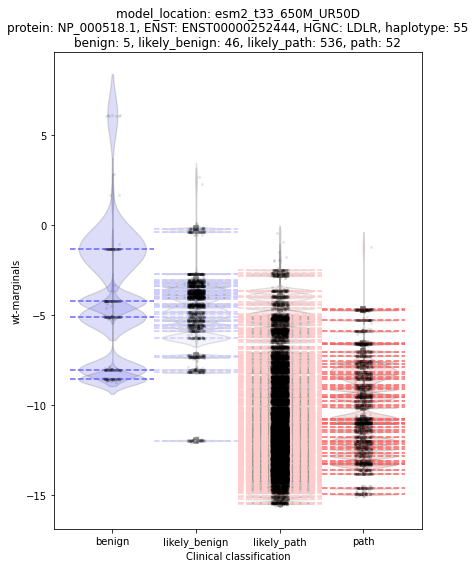

In [13]:
va.plot_vep_violin(vep_df, 
                   model_location="esm2_t33_650M_UR50D",
                   max_proteins=1,
                   max_models=1,
                   scoring_strategy="wt-marginals")

### Violin plots: masked-marginals

Filtered 0.0% of rows with NAs in col 'VEP'


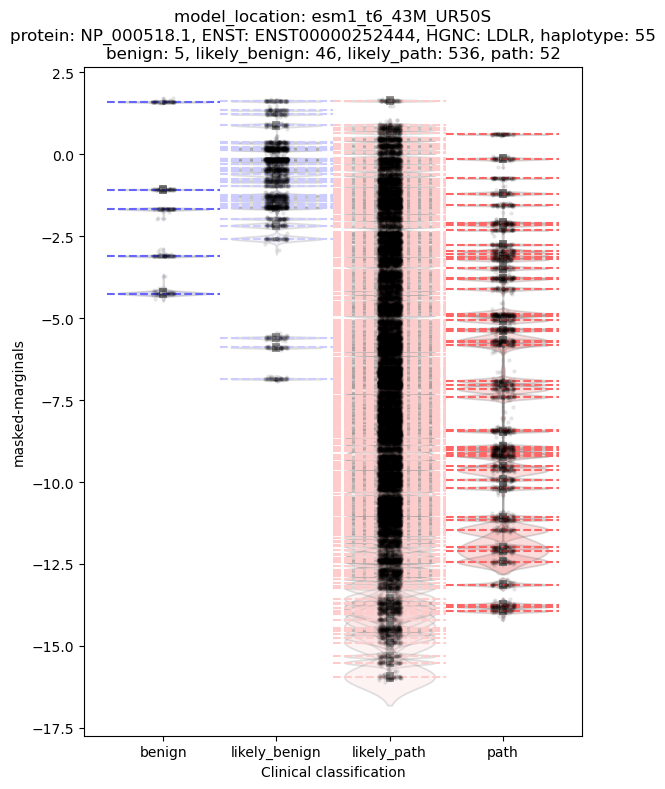

In [42]:
va.plot_vep_violin(vep_df, 
                    max_proteins=1,
                    max_models=1,
                    scoring_strategy="masked-marginals")

### Haplotype Representiveness

In [15]:
vep_df['VEP_percentile'] = vep_df.groupby(['model_location', 'protein', 'mutant','scoring_strategy'])['VEP'].rank(pct=True)
vep_df[['VEP_percentile']]

,VEP_percentile
0,0.218182
1,0.527273
2,0.272727
3,0.427273
4,0.400000
...,...
1102123,0.777778
1102124,0.851852
1102125,0.907407
1102126,0.064220


### Reference Representativeness: Percentiles

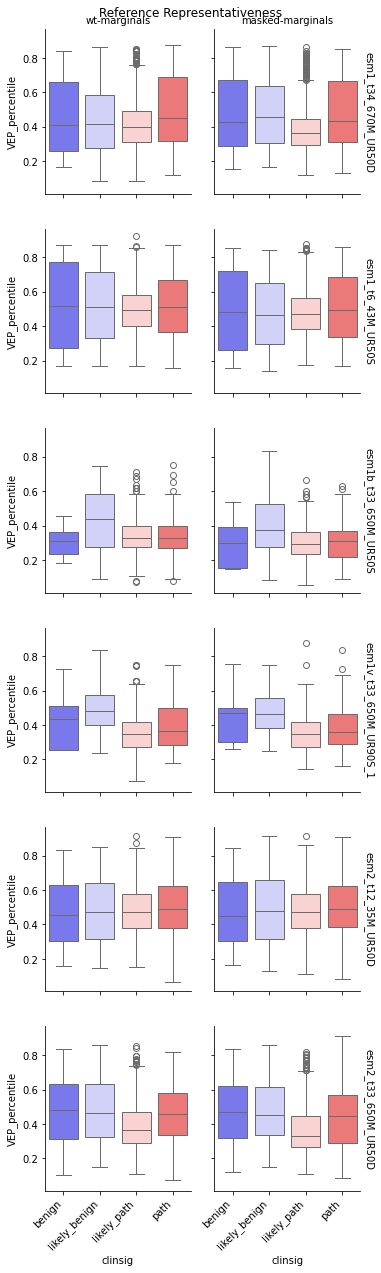

In [16]:
va.plot_vep_percentiles(vep_df)

In [17]:
vep_df.loc[vep_df['is_ref']==True]['VEP_percentile'].describe()

count    14876.000000
mean         0.438028
std          0.167548
min          0.054545
25%          0.309091
50%          0.418182
75%          0.545455
max          0.923077
Name: VEP_percentile, dtype: float64

## Precision-Recall 

In [3]:
# Add the number of edits (variants relative to the reference) per haplotype
vep_df = utils.add_edits(vep_df)

# Scale edits by protein sequence length
seq_lens = {seq:len(seq) for seq in vep_df['protein_sequence']}
vep_df['protein_sequence_len'] = vep_df['protein_sequence'].map(seq_lens)
vep_df['edits_scaled'] = vep_df['edits'] / vep_df['protein_sequence_len']
vep_df['edits_clipped'] = vep_df['edits'].clip(upper=20)

# vep_df['edits_scaled_quartiles'] = pd.qcut(vep_df.groupby(['protein','mutant'])['edits_scaled'], q=10, labels=False)
# vep_df['edits_scaled_quartiles'].value_counts()

Filter to only include variants with high-confidence annotations.

In [17]:
print(vep_df.groupby("clinsig")['CLNREVSTAT'].value_counts())

vep_qc = vep_df.loc[(vep_df['clinsig'].isin(["path","benign"])) &\
                    (vep_df['CLNREVSTAT'].isin(['reviewed_by_expert_panel','practice_guideline']))]

clinsig        CLNREVSTAT                                          
benign         reviewed_by_expert_panel                                116046
               criteria_provided,_single_submitter                       7712
               criteria_provided,_multiple_submitters,_no_conflicts       720
likely_benign  criteria_provided,_single_submitter                     139546
               criteria_provided,_multiple_submitters,_no_conflicts     48290
               reviewed_by_expert_panel                                  2640
likely_path    criteria_provided,_multiple_submitters,_no_conflicts    269182
               criteria_provided,_single_submitter                     246258
               reviewed_by_expert_panel                                 26400
path           reviewed_by_expert_panel                                151532
               criteria_provided,_single_submitter                      60022
               criteria_provided,_multiple_submitters,_no_conflicts     25

In [15]:
vep_pr = va.compute_precision_recall(vep_qc,
                                     groupby_cols = ['model_location', 'scoring_strategy',
                                                     'is_ref','haplotype','edits'],
                                     x='VEP',
                                     y='DMS_bin_score')
# Add back in extra cols
vep_df['protein_sequence_len'] = vep_df['protein_sequence'].map(seq_lens)
vep_df['edits_scaled'] = vep_df['edits'] / vep_df['protein_sequence_len']
vep_pr['edits_clipped'] = vep_pr['edits'].clip(upper=20)

Binarizing pathogenic vs benign labels


Computing precision and recall:   0%|          | 0/2624 [00:00<?, ?it/s]

/grid/koo/home/schilder/.local/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


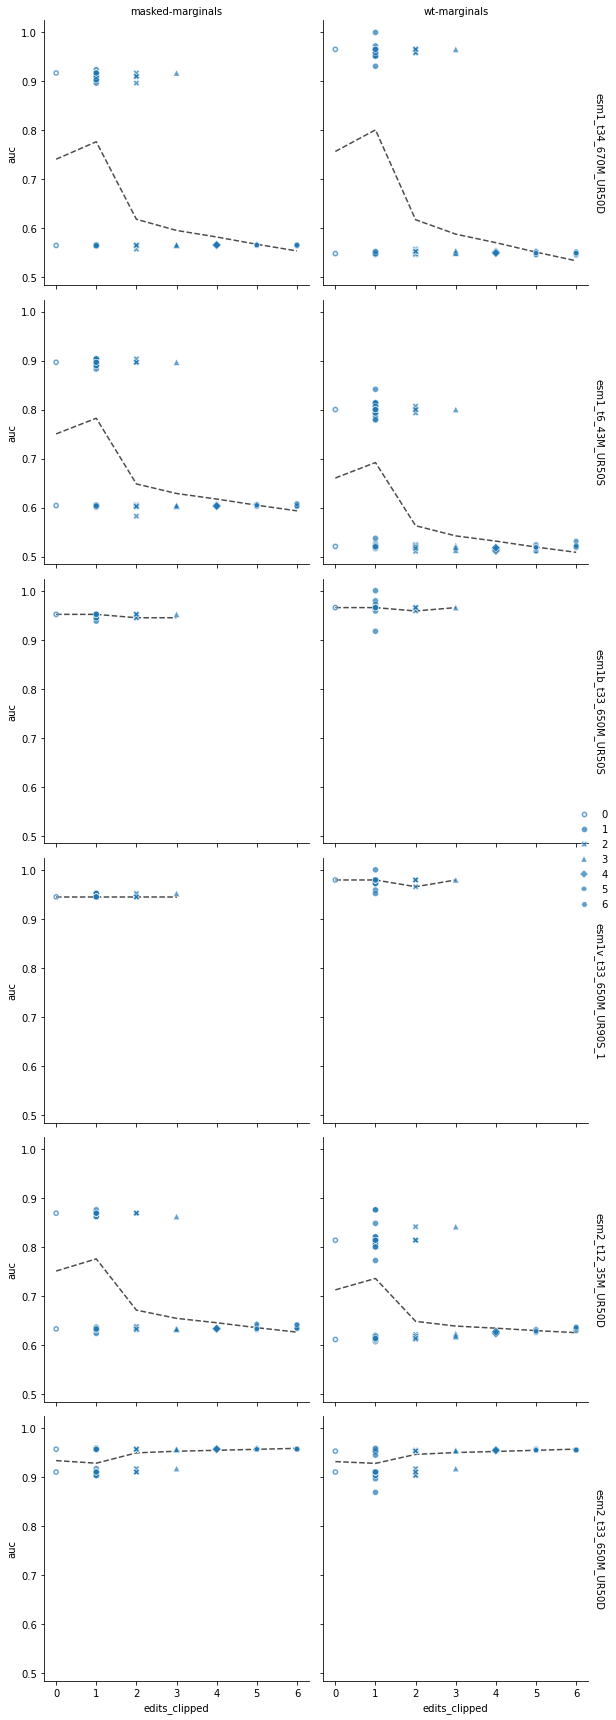

In [24]:
va.plot_auc_by_edits(vep_pr, #vep_pr.loc[vep_pr['edits'] < 20],
                     x="edits_clipped")

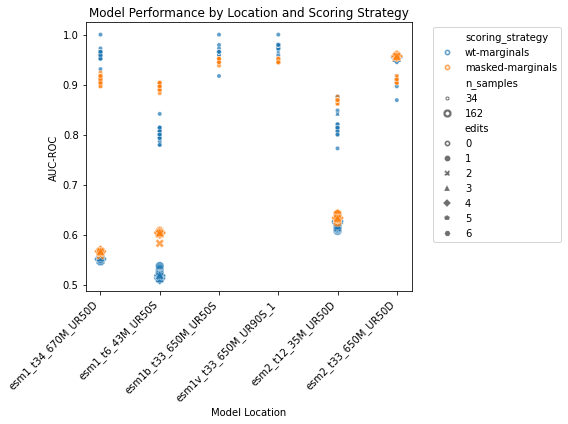

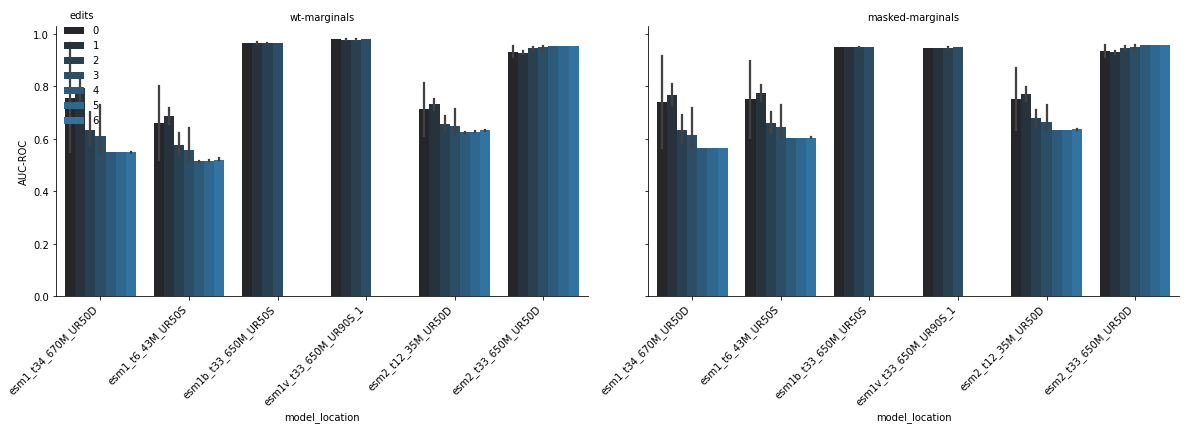

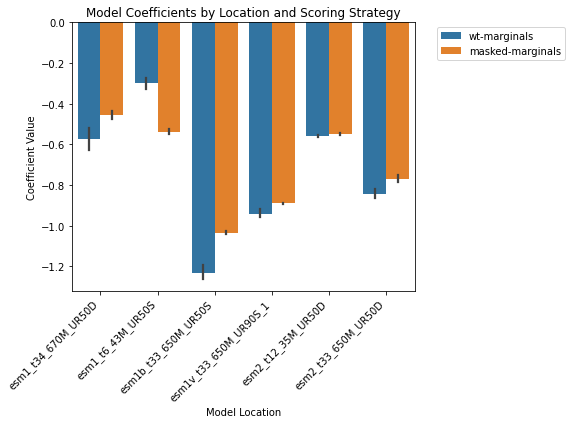

In [ ]:
va.plot_precision_recall(vep_pr,
                        style='edits',
                        hue='scoring_strategy')

### Pairwise correlations between haplotypes
Compute pairwise correlations between all haplotypes for a given protein.

In [82]:
# Group by protein and pivot to get haplotype columns
vep_pivot = vep_df.groupby('protein').apply(lambda x: pd.pivot_table(x,
                                                                    index=['protein', 'mutant'],
                                                                    columns='edits_clipped',
                                                                    values='VEP',
                                                                    # Only include haplotypes for this protein
                                                                    dropna=True))
vep_pivot


edits_clipped                         0         1         2         3   \
protein     protein     mutant                                           
NP_000229.1 NP_000229.1 A175D  -2.003643 -2.005086 -1.993713 -1.999878   
                        A233S  -0.970764 -0.972086 -0.968051 -0.943402   
                        A32V   -5.394741 -5.390556 -5.398690 -5.410456   
                        A40V   -3.520089 -3.518756 -3.521385 -3.536407   
                        A422T  -6.273535 -6.254696 -6.271549 -6.260858   
...                                  ...       ...       ...       ...   
NP_009225.1 NP_009225.1 Y465D  -0.923920 -0.906286 -0.931287 -0.924386   
                        Y655D  -0.197413 -0.196252 -0.204921 -0.200980   
                        Y655F  -0.911646 -0.911115 -0.911507 -0.910306   
                        Y777C  -0.274064 -0.273567 -0.274368 -0.270302   
                        Y856H  -0.193976 -0.142583 -0.194329 -0.188254   

edits_clipped                         4         5         6   20  
protein     protein     mutant                                    
NP_000229.1 NP_000229.1 A175D        NaN       NaN       NaN NaN  
                        A233S        NaN       NaN       NaN NaN  
                        A32V         NaN       NaN       NaN NaN  
                        A40V         NaN       NaN       NaN NaN  
                        A422T        NaN       NaN       NaN NaN  
...                                  ...       ...       ...  ..  
NP_009225.1 NP_009225.1 Y465D  -0.934882 -0.936071 -0.938104 NaN  
                        Y655D  -0.205540 -0.206046 -0.202440 NaN  
                        Y655F  -0.910815 -0.908769 -0.908850 NaN  
                        Y777C  -0.281388 -0.273003 -0.273906 NaN  
                        Y856H  -0.197819 -0.194985 -0.194042 NaN  

[1508 rows x 8 columns]

In [84]:
vep_pivot.index.get_level_values('mutant').value_counts()

# Calculate percentage of non-NA values for each row
pct_nonna = (vep_pivot.notna().sum(axis=0) / vep_pivot.shape[0] * 100).round(2)

pct_nonna.describe()


count      8.000000
mean      62.136250
std       39.890232
min       10.610000
25%       30.240000
50%       63.000000
75%      100.000000
max      100.000000
dtype: float64

In [114]:
vep_pivot.index.get_level_values(0).nunique()

6

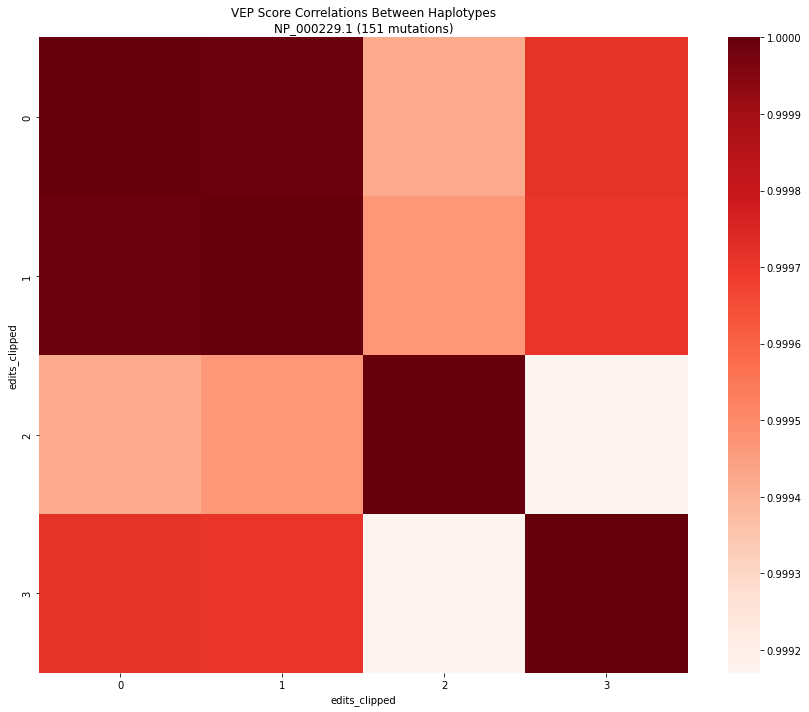

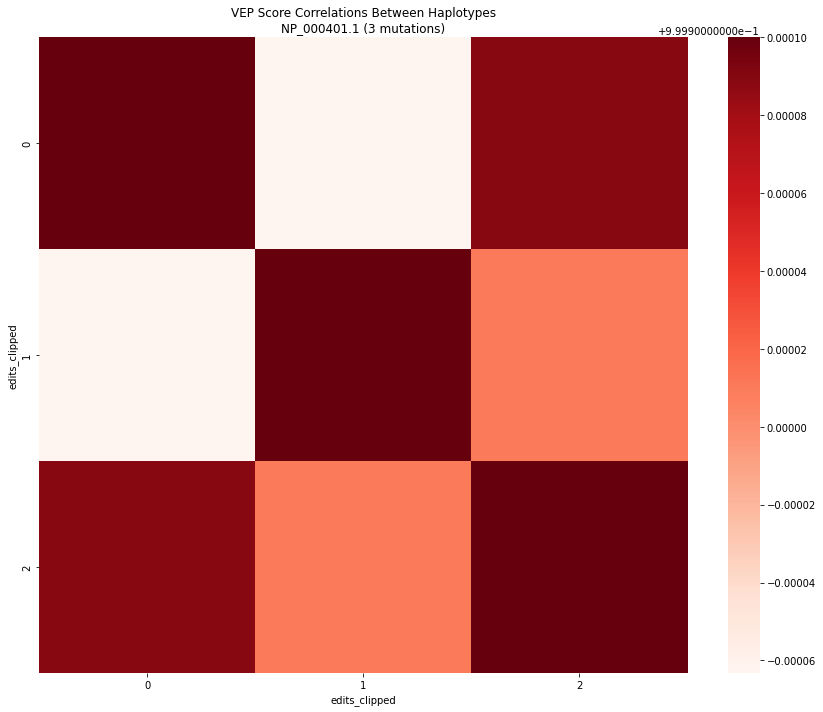

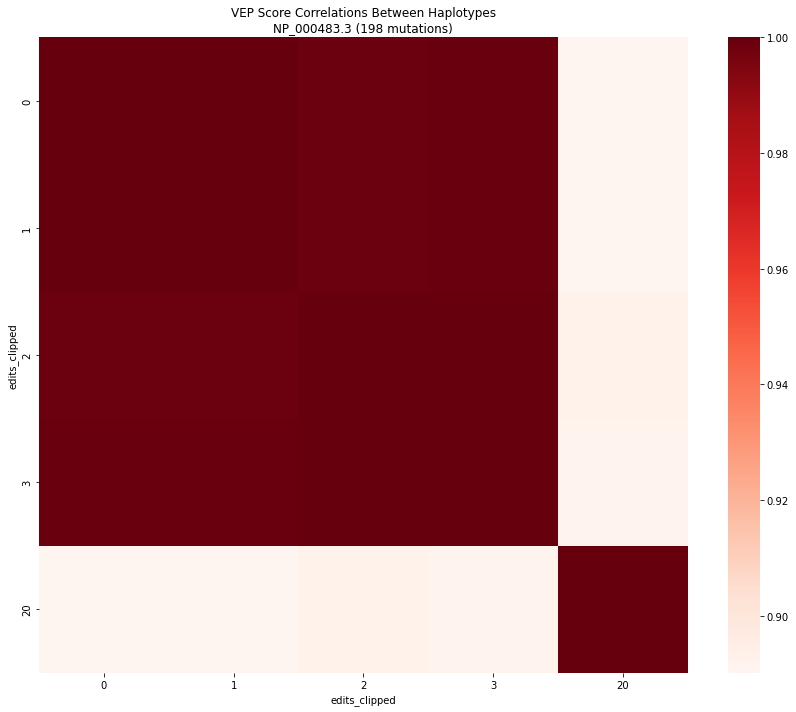

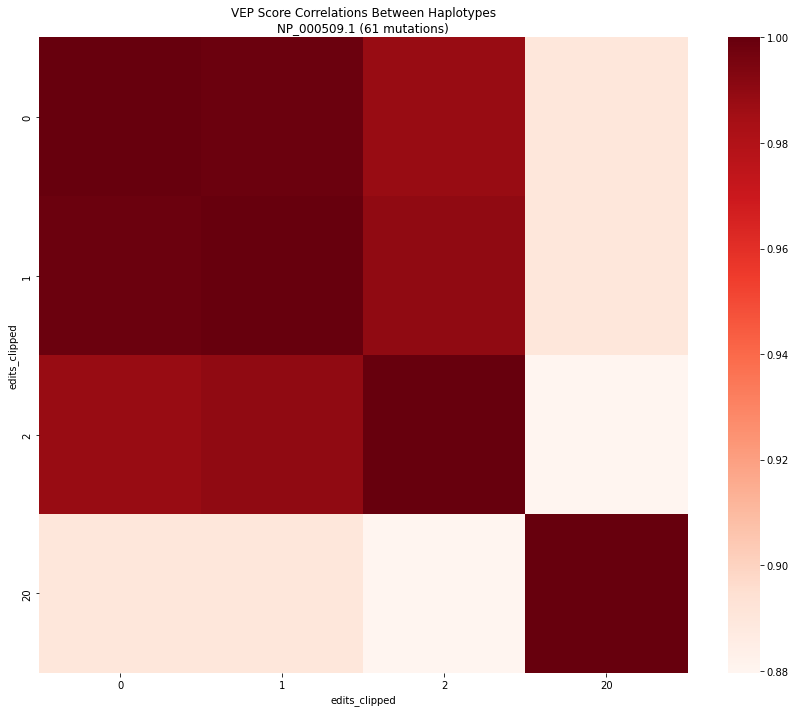

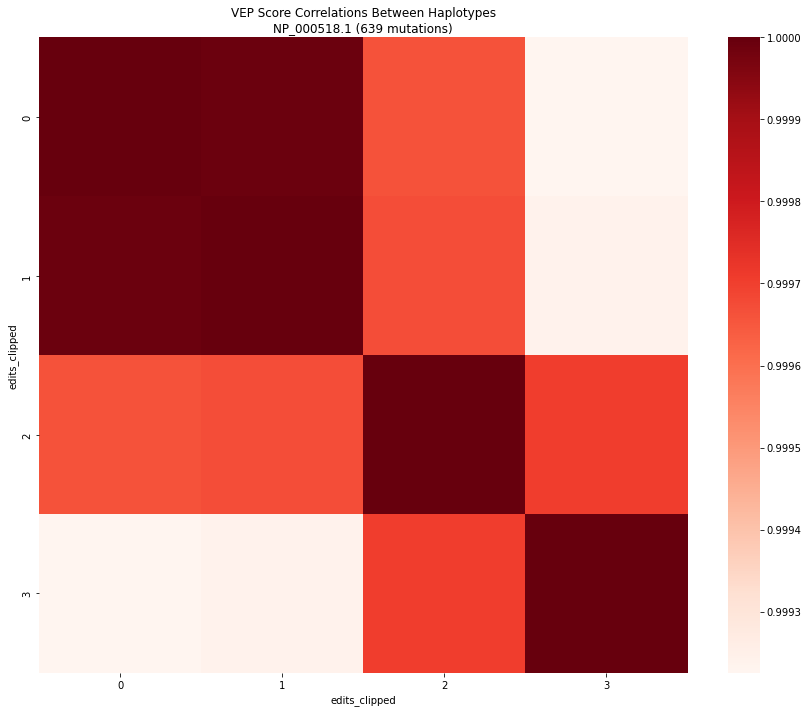

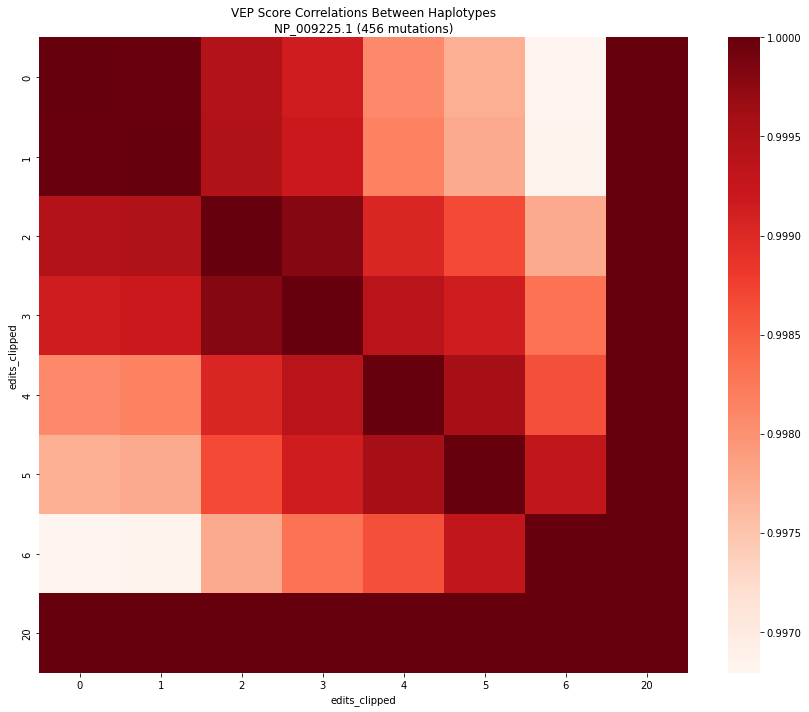

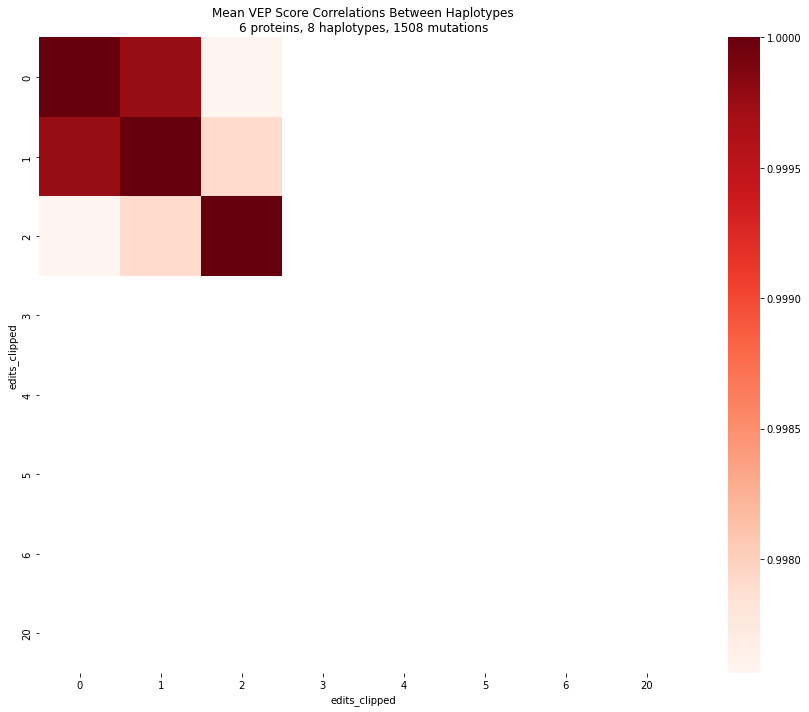

In [116]:
# Compute correlations within each protein
vep_corr = vep_pivot.groupby('protein').apply(lambda x: x.corr())
import matplotlib.pyplot as plt
import seaborn as sns
# Create list to store correlation matrices
corr_matrices = []

# Get correlation matrix for each protein
for protein in vep_corr.index.get_level_values(0).unique():
    corr_matrix = vep_corr.loc[protein]
    # Remove columns that are all NA
    corr_matrix = corr_matrix.dropna(axis=1, how='all')
    # Remove rows that are all NA 
    corr_matrix = corr_matrix.dropna(axis=0, how='all')
    plt.figure(figsize=(12,10))
    sns.heatmap(corr_matrix,
                cmap='Reds', 
                # center=vep_corr.mean().mean(),
                # vmin=vep_corr.min().min(),
                # vmax=vep_corr.max().max()
                )
    n_mutations = len(vep_pivot.loc[protein].index)
    plt.title(f'VEP Correlations Between Haplotypes\n{protein} ({n_mutations} mutations)')
    plt.tight_layout()
    plt.show()
    corr_matrices.append(corr_matrix)

# Calculate mean correlation matrix
mean_corr = sum(corr_matrices) / len(corr_matrices)

# Plot mean correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(mean_corr,
            cmap='Reds',
            )
plt.title(f'Mean VEP Correlations Between Haplotypes\n{vep_pivot.index.get_level_values(0).nunique()} proteins, {len(vep_pivot.columns)} haplotypes, {len(vep_pivot.index)} mutations')
plt.tight_layout()
plt.show()
